# Exploratory Data Analysis and Hypothesis Tests

This notebook performs exploratory data analysis and preliminary hypothesis tests for the Syria host-country panel.

## Scope

- Origin country: Syria
- Host countries: neighboring and major Syrian refugee host countries
- Host groups: neighboring hosts, regional non-neighbor host, and non-neighbor European hosts
- Time period: 2010–2024

## Purpose

The purpose of this notebook is to:

- assess data quality and missingness
- visualize conflict intensity, refugee burden, and macroeconomic outcomes
- compare refugee exposure across host groups
- test whether refugee burden is associated with selected macroeconomic indicators

## Important Note

This analysis is descriptive and associative. The results should not be interpreted as causal effects.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu

REPO_ROOT = Path("..")
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
OUTPUTS_DIR = REPO_ROOT / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
TABLE_DIR = OUTPUTS_DIR / "tables"

for p in [FIG_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

panel_path = PROCESSED_DIR / "syria_panel_2010_2024.csv"
df = pd.read_csv(panel_path)

print(df.shape)
print(df.head())
print(df.dtypes)

(135, 17)
  origin_name origin_iso host_name host_iso                  host_group  year  \
0       Syria        SYR   Austria      AUT  non_neighbor_european_host  2010   
1       Syria        SYR   Austria      AUT  non_neighbor_european_host  2011   
2       Syria        SYR   Austria      AUT  non_neighbor_european_host  2012   
3       Syria        SYR   Austria      AUT  non_neighbor_european_host  2013   
4       Syria        SYR   Austria      AUT  non_neighbor_european_host  2014   

   conflict_bd_best_syria  refugee_stock  asylum_seekers  host_population  \
0                     0.0            505             471        8363404.0   
1                  1203.0            903             456        8391643.0   
2                 50490.0           1675             694        8429991.0   
3                 72016.0           2748            1561        8479823.0   
4                 65345.0           6653               0        8546356.0   

   refugees_per_1000  log_refugee_stock 

## Data Quality and Missingness

Before running any hypothesis test, the dataset must be checked for missing values.

This section reports:

- variable-level missingness
- host-level missingness
- a missingness heatmap

Missing observations are not imputed in this milestone. Hypothesis tests use complete-case observations for the variables involved in each test.

In [2]:
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ["variable", "missing_count"]
missing_summary["missing_rate"] = missing_summary["missing_count"] / len(df)

missing_summary_path = TABLE_DIR / "syria_missing_summary.csv"
missing_summary.to_csv(missing_summary_path, index=False)

print(missing_summary)
print(missing_summary_path)

                   variable  missing_count  missing_rate
0               origin_name              0      0.000000
1                origin_iso              0      0.000000
2                 host_name              0      0.000000
3                  host_iso              0      0.000000
4                host_group              0      0.000000
5                      year              0      0.000000
6    conflict_bd_best_syria              0      0.000000
7             refugee_stock              0      0.000000
8            asylum_seekers              0      0.000000
9           host_population              0      0.000000
10        refugees_per_1000              0      0.000000
11        log_refugee_stock              0      0.000000
12               gdp_growth              1      0.007407
13                inflation              0      0.000000
14             unemployment              1      0.007407
15            trade_pct_gdp              1      0.007407
16  current_account_pct_gdp    

In [3]:
missing_by_host = df.groupby("host_iso").apply(lambda x: x.isna().sum()).T
missing_by_host = missing_by_host.reset_index().rename(columns={"index": "variable"})

missing_by_host_path = TABLE_DIR / "syria_missing_by_host.csv"
missing_by_host.to_csv(missing_by_host_path, index=False)

print(missing_by_host)
print(missing_by_host_path)

host_iso                 variable  AUT  DEU  EGY  IRQ  JOR  LBN  NLD  SWE  TUR
0                     origin_name    0    0    0    0    0    0    0    0    0
1                      origin_iso    0    0    0    0    0    0    0    0    0
2                       host_name    0    0    0    0    0    0    0    0    0
3                      host_group    0    0    0    0    0    0    0    0    0
4                            year    0    0    0    0    0    0    0    0    0
5          conflict_bd_best_syria    0    0    0    0    0    0    0    0    0
6                   refugee_stock    0    0    0    0    0    0    0    0    0
7                  asylum_seekers    0    0    0    0    0    0    0    0    0
8                 host_population    0    0    0    0    0    0    0    0    0
9               refugees_per_1000    0    0    0    0    0    0    0    0    0
10              log_refugee_stock    0    0    0    0    0    0    0    0    0
11                     gdp_growth    0    0    0    

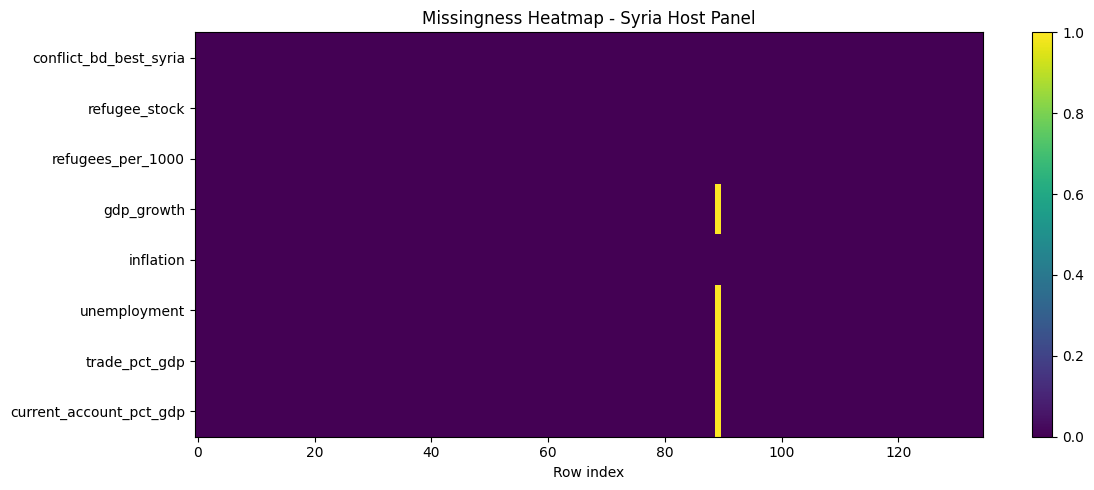

../outputs/figures/syria_missingness_heatmap.png


In [4]:
plot_vars = [
    "conflict_bd_best_syria",
    "refugee_stock",
    "refugees_per_1000",
    "gdp_growth",
    "inflation",
    "unemployment",
    "trade_pct_gdp",
    "current_account_pct_gdp",
]

missing_matrix = df[plot_vars].isna().astype(int).T

plt.figure(figsize=(12, 5))
plt.imshow(missing_matrix, aspect="auto")
plt.yticks(range(len(plot_vars)), plot_vars)
plt.xlabel("Row index")
plt.title("Missingness Heatmap - Syria Host Panel")
plt.colorbar()

missing_heatmap_path = FIG_DIR / "syria_missingness_heatmap.png"
plt.tight_layout()
plt.savefig(missing_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print(missing_heatmap_path)

## Exploratory Data Analysis

This section visualizes:

- annual conflict intensity in Syria
- refugee burden across host countries
- host-country macroeconomic indicators over time
- bivariate relationships between refugee burden and selected outcomes

The goal is to understand the shape, scale, and variation of the data before interpreting test results.

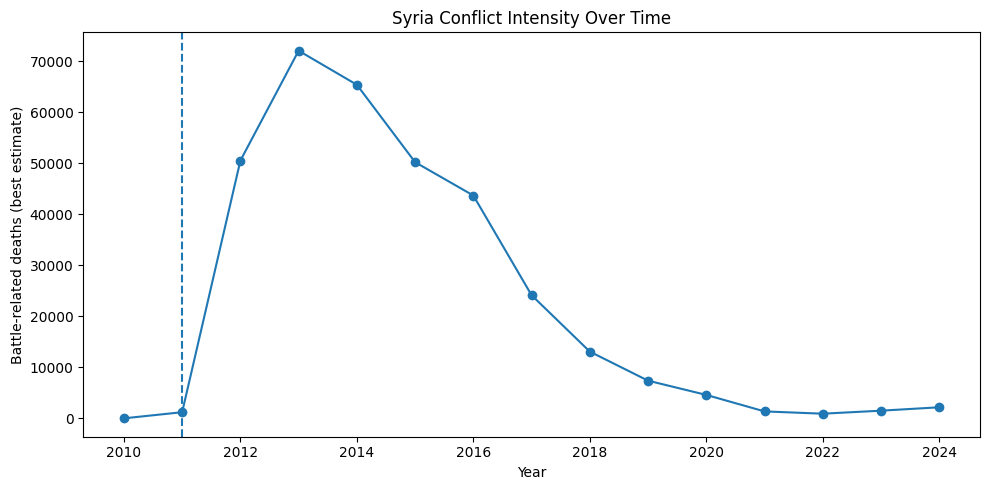

../outputs/figures/syria_conflict_intensity.png


In [5]:
conflict_ts = (
    df[["year", "conflict_bd_best_syria"]]
    .drop_duplicates()
    .sort_values("year")
)

plt.figure(figsize=(10, 5))
plt.plot(conflict_ts["year"], conflict_ts["conflict_bd_best_syria"], marker="o")
plt.axvline(2011, linestyle="--")
plt.title("Syria Conflict Intensity Over Time")
plt.xlabel("Year")
plt.ylabel("Battle-related deaths (best estimate)")

path_conflict = FIG_DIR / "syria_conflict_intensity.png"
plt.tight_layout()
plt.savefig(path_conflict, dpi=200, bbox_inches="tight")
plt.show()

print(path_conflict)

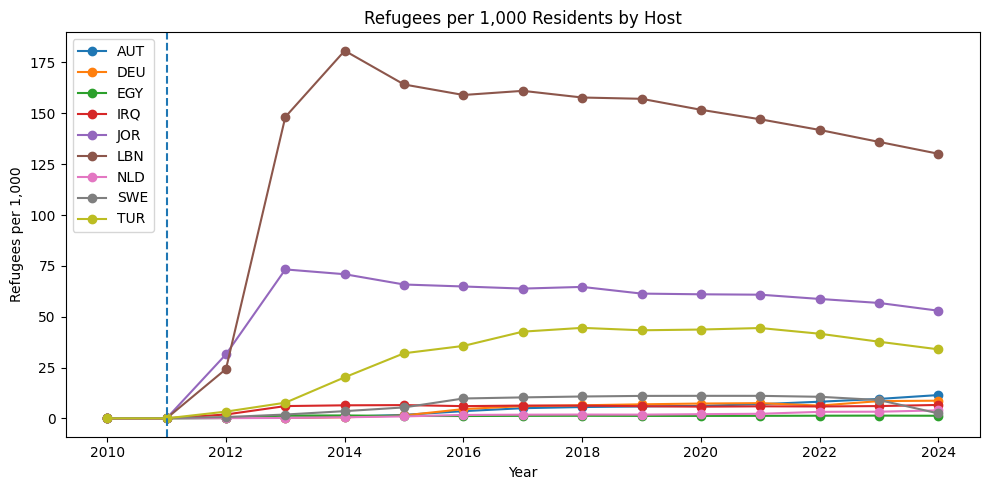

../outputs/figures/syria_refugees_per_1000_by_host.png


In [6]:
plt.figure(figsize=(10, 5))

for host in sorted(df["host_iso"].unique()):
    sub = df[df["host_iso"] == host].sort_values("year")
    plt.plot(sub["year"], sub["refugees_per_1000"], marker="o", label=host)

plt.axvline(2011, linestyle="--")
plt.title("Refugees per 1,000 Residents by Host")
plt.xlabel("Year")
plt.ylabel("Refugees per 1,000")
plt.legend()

path_refugee = FIG_DIR / "syria_refugees_per_1000_by_host.png"
plt.tight_layout()
plt.savefig(path_refugee, dpi=200, bbox_inches="tight")
plt.show()

print(path_refugee)

In [7]:
def plot_macro_by_host(data, y_col, title, out_name):
    plt.figure(figsize=(10, 5))

    for host in sorted(data["host_iso"].unique()):
        sub = data[data["host_iso"] == host].sort_values("year")
        plt.plot(sub["year"], sub[y_col], marker="o", label=host)

    plt.axvline(2011, linestyle="--")
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(y_col)
    plt.legend()

    out_path = FIG_DIR / out_name
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(out_path)

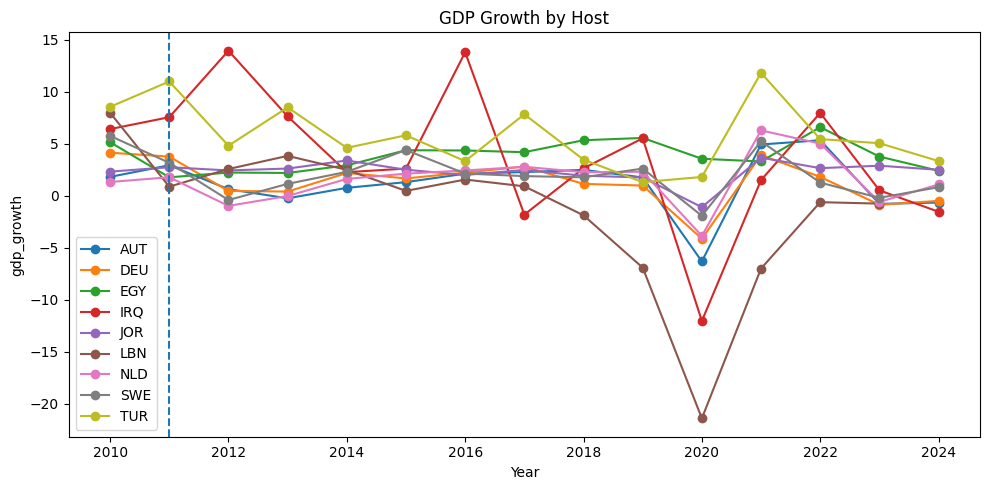

../outputs/figures/syria_gdp_growth_by_host.png


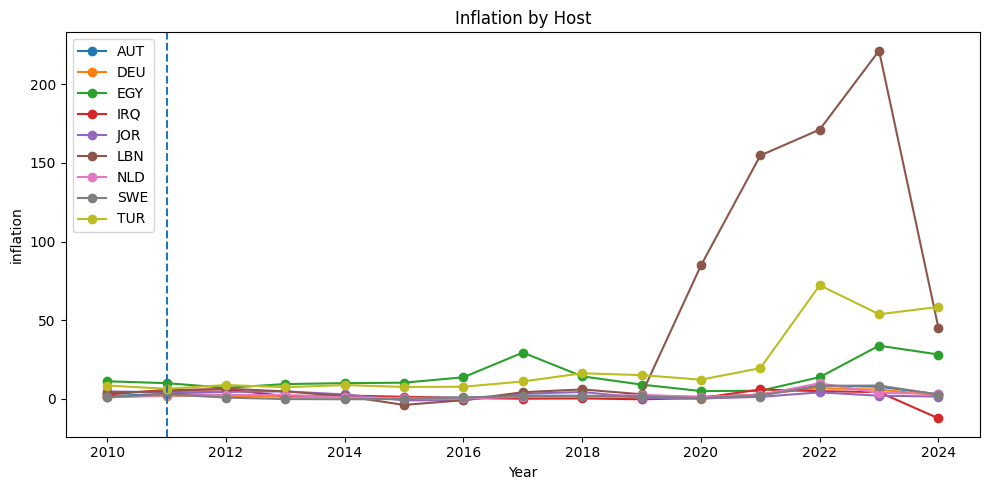

../outputs/figures/syria_inflation_by_host.png


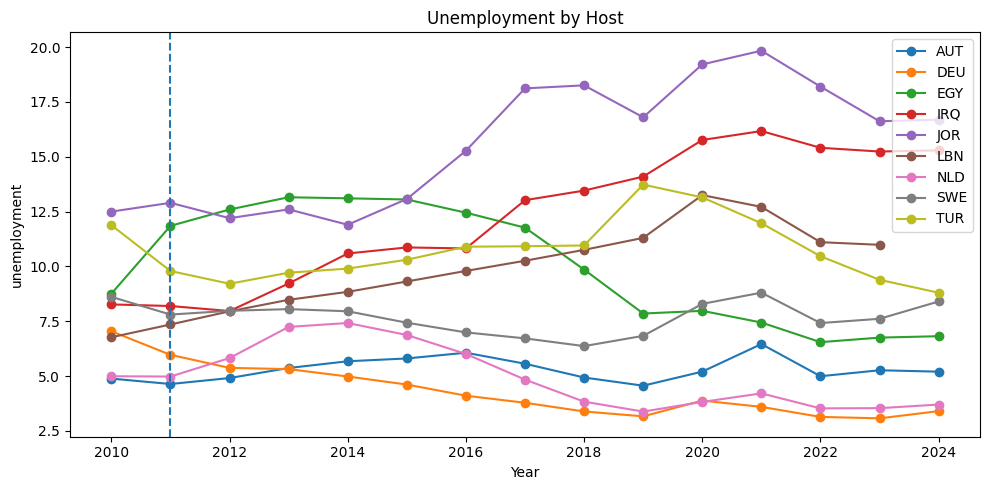

../outputs/figures/syria_unemployment_by_host.png


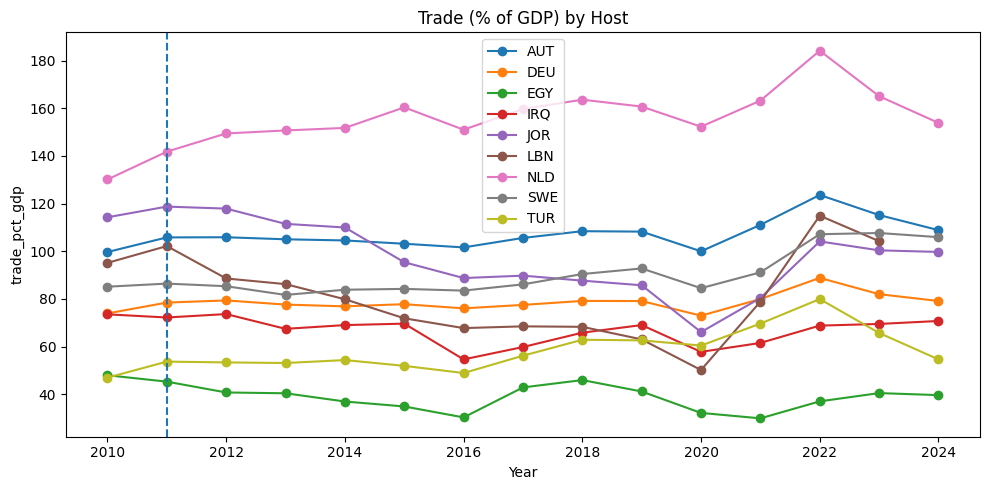

../outputs/figures/syria_trade_pct_gdp_by_host.png


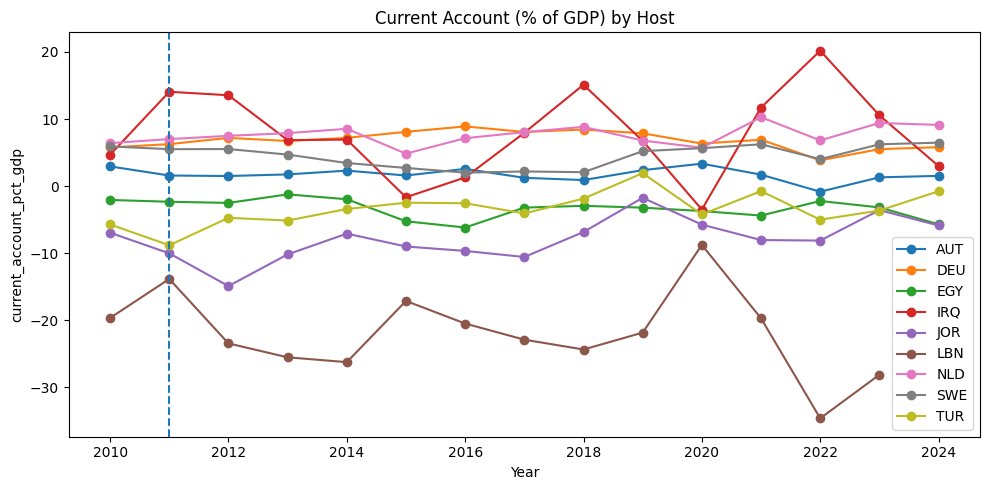

../outputs/figures/syria_current_account_by_host.png


In [8]:
plot_macro_by_host(df, "gdp_growth", "GDP Growth by Host", "syria_gdp_growth_by_host.png")
plot_macro_by_host(df, "inflation", "Inflation by Host", "syria_inflation_by_host.png")
plot_macro_by_host(df, "unemployment", "Unemployment by Host", "syria_unemployment_by_host.png")
plot_macro_by_host(df, "trade_pct_gdp", "Trade (% of GDP) by Host", "syria_trade_pct_gdp_by_host.png")
plot_macro_by_host(df, "current_account_pct_gdp", "Current Account (% of GDP) by Host", "syria_current_account_by_host.png")

In [9]:
def scatter_exposure_vs_outcome(df, outcome_col, filename):
    """Plot all host-year observations with clearer grouping and limited labels."""

    plot_df = df.dropna(
        subset=["refugees_per_1000", outcome_col, "host_group", "host_name", "year"]
    ).copy()

    plt.figure(figsize=(10, 6))

    for group in sorted(plot_df["host_group"].unique()):
        group_df = plot_df[plot_df["host_group"] == group]

        plt.scatter(
            group_df["refugees_per_1000"],
            group_df[outcome_col],
            alpha=0.65,
            s=55,
            label=group
        )

    # Add a simple trend line only if enough data points exist
    x = plot_df["refugees_per_1000"]
    y = plot_df[outcome_col]

    if len(plot_df) >= 2 and x.nunique() > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        plt.plot(x_line, p(x_line), linestyle="--", linewidth=2, label="Trend line")

    # Label only latest-year observations to avoid visual clutter
    latest_year = plot_df["year"].max()
    latest_df = plot_df[plot_df["year"] == latest_year]

    for _, row in latest_df.iterrows():
        plt.annotate(
            row["host_name"],
            (row["refugees_per_1000"], row[outcome_col]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points"
        )

    plt.xlabel("Refugees per 1,000 people")
    plt.ylabel(outcome_col.replace("_", " ").title())
    plt.title(f"Refugee Exposure vs {outcome_col.replace('_', ' ').title()}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    output_path = FIG_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure to:", output_path)


def scatter_country_means(df, outcome_col, filename):
    """Plot one point per host country using average refugee exposure and average outcome."""

    plot_df = df.dropna(
        subset=["refugees_per_1000", outcome_col, "host_group", "host_name"]
    ).copy()

    avg_df = (
        plot_df
        .groupby(["host_name", "host_group"], as_index=False)
        .agg({
            "refugees_per_1000": "mean",
            outcome_col: "mean"
        })
    )

    plt.figure(figsize=(10, 6))

    for group in sorted(avg_df["host_group"].unique()):
        group_df = avg_df[avg_df["host_group"] == group]

        plt.scatter(
            group_df["refugees_per_1000"],
            group_df[outcome_col],
            s=100,
            alpha=0.8,
            label=group
        )

    for _, row in avg_df.iterrows():
        plt.annotate(
            row["host_name"],
            (row["refugees_per_1000"], row[outcome_col]),
            fontsize=9,
            xytext=(5, 5),
            textcoords="offset points"
        )

    plt.xlabel("Average Refugees per 1,000 people")
    plt.ylabel(f"Average {outcome_col.replace('_', ' ').title()}")
    plt.title(f"Average Refugee Exposure vs Average {outcome_col.replace('_', ' ').title()}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    output_path = FIG_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure to:", output_path)


## Bivariate Association Plots

This section visualizes the relationship between refugee burden and selected macroeconomic outcomes.

The first scatter plot uses all host-year observations and colors the points by host group. The second plot uses country averages, which is easier to read after expanding the dataset.


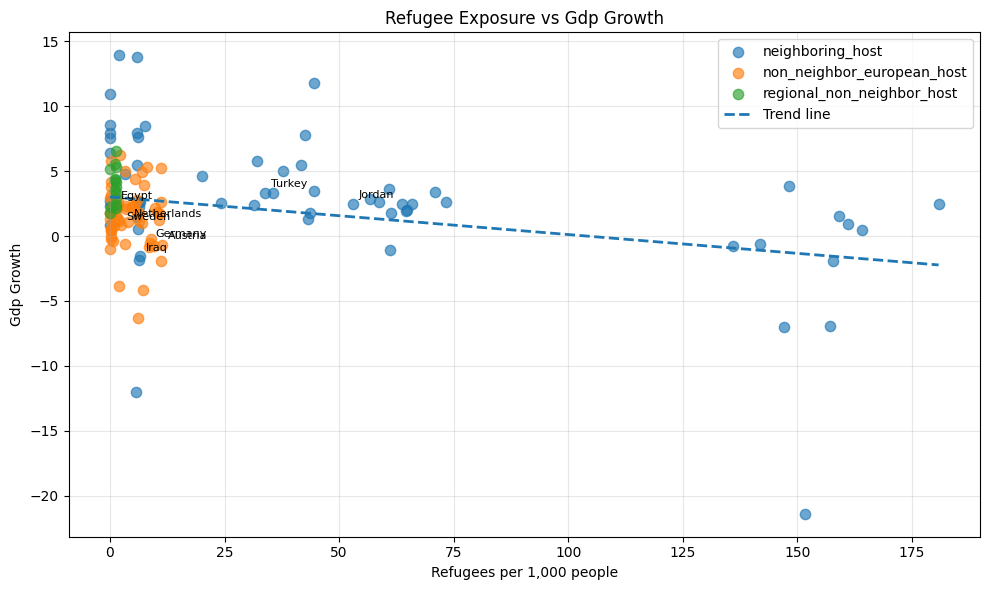

Saved figure to: ../outputs/figures/syria_scatter_refugees_vs_gdp_growth.png


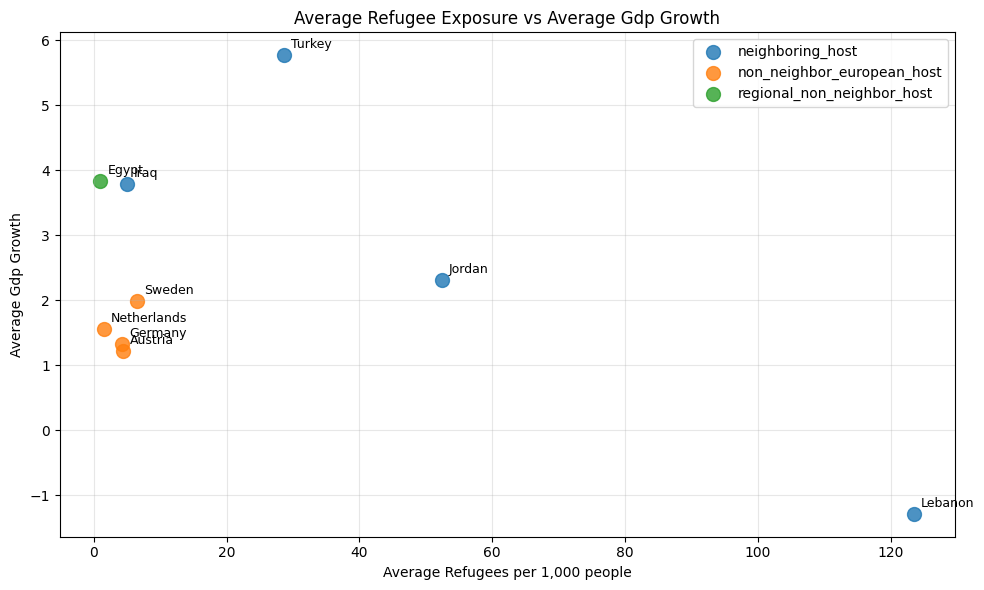

Saved figure to: ../outputs/figures/syria_scatter_country_means_gdp_growth.png


In [10]:
scatter_exposure_vs_outcome(
    df,
    "gdp_growth",
    "syria_scatter_refugees_vs_gdp_growth.png"
)

scatter_country_means(
    df,
    "gdp_growth",
    "syria_scatter_country_means_gdp_growth.png"
)


## Hypotheses and Statistical Tests

The following preliminary hypotheses are evaluated:

### H1
Higher refugee burden is associated with lower GDP growth in host countries.

### H2
Higher refugee burden is associated with inflation in host countries.

## Methods

Two types of tests are used:

1. **Spearman correlation**
   - used to test monotonic association between `refugees_per_1000` and each macroeconomic outcome

2. **Mann–Whitney U test**
   - used after splitting observations into low- and high-refugee-burden groups based on the median of `refugees_per_1000`

These tests are exploratory and do not establish causality.

In [11]:
test_results = []

def add_spearman_test(data, x_col, y_col):
    temp = data[[x_col, y_col]].dropna().copy()
    n = len(temp)

    if n < 3:
        test_results.append({
            "test": "spearman",
            "x": x_col,
            "y": y_col,
            "n": n,
            "statistic": np.nan,
            "p_value": np.nan,
            "note": "not enough observations"
        })
        return

    stat, p = spearmanr(temp[x_col], temp[y_col])
    test_results.append({
        "test": "spearman",
        "x": x_col,
        "y": y_col,
        "n": n,
        "statistic": stat,
        "p_value": p,
        "note": ""
    })

def add_mannwhitney_test(data, burden_col, outcome_col):
    temp = data[[burden_col, outcome_col]].dropna().copy()
    n = len(temp)

    if n < 4:
        test_results.append({
            "test": "mannwhitney",
            "x": burden_col,
            "y": outcome_col,
            "n": n,
            "statistic": np.nan,
            "p_value": np.nan,
            "note": "not enough observations"
        })
        return

    cutoff = temp[burden_col].median()
    low_group = temp[temp[burden_col] <= cutoff][outcome_col]
    high_group = temp[temp[burden_col] > cutoff][outcome_col]

    if len(low_group) == 0 or len(high_group) == 0:
        test_results.append({
            "test": "mannwhitney",
            "x": burden_col,
            "y": outcome_col,
            "n": n,
            "statistic": np.nan,
            "p_value": np.nan,
            "note": "empty comparison group"
        })
        return

    stat, p = mannwhitneyu(low_group, high_group, alternative="two-sided")
    test_results.append({
        "test": "mannwhitney",
        "x": burden_col,
        "y": outcome_col,
        "n": n,
        "statistic": stat,
        "p_value": p,
        "note": f"median split at {cutoff:.4f}"
    })

add_spearman_test(df, "refugees_per_1000", "inflation")
add_spearman_test(df, "refugees_per_1000", "gdp_growth")
add_mannwhitney_test(df, "refugees_per_1000", "inflation")
add_mannwhitney_test(df, "refugees_per_1000", "gdp_growth")

test_results_df = pd.DataFrame(test_results)

test_results_path = TABLE_DIR / "syria_hypothesis_tests.csv"
test_results_df.to_csv(test_results_path, index=False)

print(test_results_df)
print(test_results_path)

          test                  x           y    n    statistic   p_value  \
0     spearman  refugees_per_1000   inflation  135     0.058887  0.497498   
1     spearman  refugees_per_1000  gdp_growth  134    -0.177012  0.040751   
2  mannwhitney  refugees_per_1000   inflation  135  2114.000000  0.471816   
3  mannwhitney  refugees_per_1000  gdp_growth  134  2558.000000  0.163676   

                     note  
0                          
1                          
2  median split at 5.9674  
3  median split at 5.9388  
../outputs/tables/syria_hypothesis_tests.csv


## Interpretation of Preliminary Test Results

The hypothesis tests are exploratory and should be interpreted carefully.

The Spearman correlation checks whether refugee burden and macroeconomic outcomes move together in a monotonic way.

The Mann–Whitney U test compares observations with low and high refugee burden based on the median value of `refugees_per_1000`.

These results show associations in the panel, but they do not prove that refugee exposure caused changes in GDP growth or inflation.


In [12]:
summary_stats = df[[
    "conflict_bd_best_syria",
    "refugee_stock",
    "refugees_per_1000",
    "gdp_growth",
    "inflation",
    "unemployment",
    "trade_pct_gdp",
    "current_account_pct_gdp"
]].describe()

summary_stats_path = TABLE_DIR / "syria_summary_stats.csv"
summary_stats.to_csv(summary_stats_path)

print(summary_stats)
print(summary_stats_path)

       conflict_bd_best_syria  refugee_stock  refugees_per_1000  gdp_growth  \
count              135.000000   1.350000e+02         135.000000  134.000000   
mean             22532.266667   4.925781e+05          25.321489    2.309117   
std              25462.347182   8.633695e+05          44.425463    4.054462   
min                  0.000000   8.000000e+00           0.000090  -21.399900   
25%               1356.000000   3.090450e+04           1.211542    1.003552   
50%               7379.000000   1.292100e+05           5.967396    2.297932   
75%              50181.000000   6.256675e+05          31.740615    3.889468   
max              72016.000000   3.737369e+06         180.793415   13.936430   

        inflation  unemployment  trade_pct_gdp  current_account_pct_gdp  
count  135.000000    134.000000     134.000000               134.000000  
mean    10.682347      8.971672      86.172888                -0.723378  
std     29.256365      4.040092      33.229635                 9.5

## Notebook Output

This notebook saves the main EDA and hypothesis testing outputs under:

- `outputs/figures/`
- `outputs/tables/`

These outputs include:

- missingness summaries
- EDA figures
- refugee exposure scatter plots
- hypothesis test results
- summary statistics
